# Chess Player Tier Classification
Classifies each player's Elo into skill tiers using board features + clock features.

**Tiers**
| Label | Elo range |
|---|---|
| Beginner | < 1000 |
| Novice | 1000–1200 |
| Intermediate | 1200–1600 |
| Expert | 1600–1800 |
| Advanced | 1800–2000 |
| Pro | 2000–2200 |
| Master/GM | ≥ 2200 |

**Pipeline**
1. Same data loader + feature engineering as `chess_elo_v_final`
2. Tier label encoding
3. Train / Val / Test split + class weights
4. Pluggable model backend: **LightGBM** and **XGBoost** (toggle via `MODEL_BACKEND`)
5. Optional hyperparameter search
6. Confusion matrix, per-class metrics, feature importance
7. Auto-save trained model

> Toggle every behaviour from the **CONFIGURATION** cell — nowhere else.


In [1]:
# pip install chess zstandard lightgbm xgboost pandas scikit-learn matplotlib seaborn joblib
import io, re, time, os, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import zstandard as zstd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    top_k_accuracy_score,
)
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint, uniform

import lightgbm as lgb
import xgboost as xgb
from joblib import Parallel, delayed

from chess_features_final import extract_features_dataframe, compute_elo_sample_weights

warnings.filterwarnings('ignore')
print('All imports OK')


All imports OK


## ⚙️ CONFIGURATION — edit here only

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

DATA_PATH    = "../../data/villads_data/lichess_db_standard_rated_2017-11.pgn.zst"
MAX_GAMES    = 500_000
RANDOM_STATE = 42
N_JOBS       = -1

# ── splits ────────────────────────────────────────────────────────────────────
VAL_SIZE  = 0.10
TEST_SIZE = 0.10

# ── time-control filter ───────────────────────────────────────────────────────
FILTER_BASE_SECONDS  = 600
FILTER_SHORT_GAMES   = True
MIN_TOTAL_PLIES      = 12
EXCLUDE_TERMINATIONS = {"Time forfeit", "Abandoned", "Unterminated"}

# ── tier definition ───────────────────────────────────────────────────────────
# Defines ELO bin edges and human-readable tier names.
# Edit freely — the rest of the notebook adapts automatically.
TIER_BINS  = [0, 1000, 1200, 1600, 1800, 2000, 2200, 4000]
TIER_NAMES = ['Beginner', 'Novice', 'Intermediate', 'Expert', 'Advanced', 'Pro', 'Master/GM']

# Which Elo column to classify? 'WhiteElo' | 'BlackElo' | 'avg' (mean of both)
ELO_TARGET = 'avg'

# ── feature groups ────────────────────────────────────────────────────────────
FEATURE_GROUPS = {
    'structure':  True,
    'checks':     True,
    'captures':   True,
    'castling':   True,
    'style':      True,
    'clock':      True,
    'engine':     False,
    'meta':       False,
}
ADD_TIME_CONTROL_NUMERIC = True
ECO_COARSE_LEVEL         = "letter"  # only when meta=True

# ── model selection ───────────────────────────────────────────────────────────
# Switch between backends here — everything else is automatic.
MODEL_BACKEND = 'lgbm'   # 'lgbm'  or  'xgb'

# ── LightGBM params ───────────────────────────────────────────────────────────
LGBM_PARAMS = {
    'objective':         'multiclass',
    'num_class':         len(TIER_NAMES),
    'n_estimators':      600,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'class_weight':      'balanced',
    'random_state':      RANDOM_STATE,
    'verbose':           -1,
    'n_jobs':            N_JOBS,
}

# ── XGBoost params ────────────────────────────────────────────────────────────
XGB_PARAMS = {
    'objective':        'multi:softprob',
    'num_class':        len(TIER_NAMES),
    'n_estimators':     600,
    'learning_rate':    0.05,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'use_label_encoder': False,
    'eval_metric':      'mlogloss',
    'random_state':     RANDOM_STATE,
    'verbosity':        0,
    'n_jobs':           N_JOBS,
}

# ── hyperparameter search ─────────────────────────────────────────────────────
RUN_HYPERPARAM_SEARCH = False
HYPERPARAM_N_ITER     = 20
HYPERPARAM_CV_FOLDS   = 3

LGBM_SEARCH_SPACE = {
    'n_estimators':      randint(300, 900),
    'learning_rate':     uniform(0.02, 0.1),
    'num_leaves':        randint(31, 127),
    'min_child_samples': randint(10, 60),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
}
XGB_SEARCH_SPACE = {
    'n_estimators':  randint(300, 900),
    'learning_rate': uniform(0.02, 0.1),
    'max_depth':     randint(4, 10),
    'subsample':     uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

# ── pretrained model ──────────────────────────────────────────────────────────
LOAD_PRETRAINED  = False
PRETRAINED_PATH  = None   # e.g. 'tier_clf_lgbm_20250101_120000.txt'

# ── feature importance ────────────────────────────────────────────────────────
RUN_PERM_IMPORTANCE        = True
FEATURE_IMPORTANCE_METHOD  = 'gain'   # 'gain' | 'split' | 'permutation'
PERM_N_REPEATS             = 5
TOP_N_FEATURES             = 20
RETRAIN_TOP_N              = False

# ── output ────────────────────────────────────────────────────────────────────
VERBOSE_PLOTS    = True
MODEL_SAVE_NAME  = f'tier_clf_{MODEL_BACKEND}'
MODEL_SAVE_NOTES = f'{MAX_GAMES // 1_000}k_600s'

# ═══ derived — do not edit ═════════════════════════════════════════════════════
_N_CLASSES = len(TIER_NAMES)
assert len(TIER_BINS) - 1 == _N_CLASSES, "TIER_BINS must have len(TIER_NAMES)+1 edges"


## 1 · Load data

In [3]:
games_list = []
dctx = zstd.ZstdDecompressor()

t0 = time.time()
with open(DATA_PATH, 'rb') as compressed_file:
    with dctx.stream_reader(compressed_file) as reader:
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        current_game = {}
        for line in text_stream:
            line = line.strip()
            if line.startswith('['):
                tag = line.split(' ')[0][1:]
                val = line.split('"')[1]
                if tag in ('WhiteElo', 'BlackElo', 'TimeControl', 'ECO',
                           'Termination', 'Result'):
                    current_game[tag] = val
            elif line.startswith('1.'):
                current_game['Moves'] = line
                if 'WhiteElo' in current_game and 'BlackElo' in current_game:
                    games_list.append(current_game)
                current_game = {}
                if len(games_list) >= MAX_GAMES:
                    break

df_raw = pd.DataFrame(games_list)
df_raw['WhiteElo'] = pd.to_numeric(df_raw['WhiteElo'], errors='coerce')
df_raw['BlackElo'] = pd.to_numeric(df_raw['BlackElo'], errors='coerce')
df_raw = df_raw.dropna(subset=['WhiteElo', 'BlackElo']).copy()
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)
df_raw['Moves']    = df_raw['Moves'].fillna('').astype(str)
print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

if FILTER_BASE_SECONDS is not None:
    _tc_base = (
        df_raw['TimeControl'].astype(str)
        .str.extract(r'^(\d+)\+')[0]
        .astype(float)
    )
    df_raw = df_raw[_tc_base == FILTER_BASE_SECONDS].copy().reset_index(drop=True)
    print(f'After TC filter ({FILTER_BASE_SECONDS}s): {len(df_raw):,} games')

if EXCLUDE_TERMINATIONS and 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMINATIONS)].copy().reset_index(drop=True)
    print(f'After termination filter: {len(df_raw):,} (dropped {before-len(df_raw):,})')

if ADD_TIME_CONTROL_NUMERIC and 'TimeControl' in df_raw.columns:
    _tc = df_raw['TimeControl'].astype(str).str.extract(r'^(\d+)\+(\d+)')
    df_raw['tc_base']      = pd.to_numeric(_tc[0], errors='coerce').fillna(0).astype(float)
    df_raw['tc_increment'] = pd.to_numeric(_tc[1], errors='coerce').fillna(0).astype(float)

df_raw.head(3)


Loaded 500,000 games in 7.4s
After TC filter (600s): 71,196 games
After termination filter: 59,950 (dropped 11,246)


,Result,WhiteElo,BlackElo,ECO,TimeControl,Termination,Moves,tc_base,tc_increment
0,0-1,1391,1411,C20,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:05:00] }...,600.0,0.0
1,1-0,1374,1350,B30,600+0,Normal,1. e4 { [%clk 0:10:00] } c5 { [%clk 0:05:00] }...,600.0,0.0
2,1-0,1452,1463,C50,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:10:00] }...,600.0,0.0


## 2 · Clock features

In [4]:
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+)\]')

def parse_clock_features(moves_string: str, time_control: str = '?') -> dict:
    clocks = [int(h)*3600 + int(m)*60 + int(s)
              for h, m, s in _CLK_RE.findall(moves_string)]
    clk_w, clk_b = clocks[0::2], clocks[1::2]
    tc_m      = re.match(r'(\d+)\+(\d+)', str(time_control))
    base      = int(tc_m.group(1)) if tc_m else None
    increment = int(tc_m.group(2)) if tc_m else 0
    norm      = base if base else 1

    def _spent(seq, start):
        out, prev = [], start
        for c in seq:
            if prev is not None:
                s = prev - c + increment
                if s >= 0: out.append(s)
            prev = c
        return out

    sw = _spent(clk_w, base)
    sb = _spent(clk_b, base)

    def _stats(seq):
        if not seq: return 0., 0., 0.
        a = np.array(seq)
        return float(a.mean()), float(a.std()), float(a.max())

    def _trend(seq):
        if len(seq) < 2: return 0.0
        return float(np.polyfit(np.arange(len(seq)), np.array(seq, dtype=float), 1)[0])

    def _window_mean(seq, n=10, which='first'):
        if not seq: return 0.0
        return float(np.mean(seq[:n])) if which == 'first' else float(np.mean(seq[-n:]))

    aw, sw2, mw = _stats(sw); ab, sb2, mb = _stats(sb)

    return {
        'avg_time_norm_white':         aw / norm,
        'std_time_norm_white':         sw2 / norm,
        'max_time_norm_white':         mw / norm,
        'time_pressure_white':         sum(1 for c in clk_w if c < 10),
        'opening_pace_norm_white':     (np.mean(sw[:10]) if sw else 0.) / norm,
        'clock_remaining_norm_white':  (clk_w[-1] / norm) if clk_w else 0.,
        'opening_time_norm_white':     _window_mean(sw, 10, 'first') / norm,
        'endgame_time_norm_white':     _window_mean(sw, 10, 'last') / norm,
        'time_spent_trend_norm_white': _trend(sw) / norm,
        'avg_time_norm_black':         ab / norm,
        'std_time_norm_black':         sb2 / norm,
        'max_time_norm_black':         mb / norm,
        'time_pressure_black':         sum(1 for c in clk_b if c < 10),
        'opening_pace_norm_black':     (np.mean(sb[:10]) if sb else 0.) / norm,
        'clock_remaining_norm_black':  (clk_b[-1] / norm) if clk_b else 0.,
        'opening_time_norm_black':     _window_mean(sb, 10, 'first') / norm,
        'endgame_time_norm_black':     _window_mean(sb, 10, 'last') / norm,
        'time_spent_trend_norm_black': _trend(sb) / norm,
    }

if FEATURE_GROUPS['clock']:
    tc_col = df_raw['TimeControl'] if 'TimeControl' in df_raw.columns else ['?']*len(df_raw)
    clock_records = Parallel(n_jobs=N_JOBS)(
        delayed(parse_clock_features)(m, t)
        for m, t in zip(df_raw['Moves'], tc_col)
    )
    df_clocks = pd.DataFrame(clock_records, index=df_raw.index)
    print('Clock features:', df_clocks.shape)
else:
    df_clocks = pd.DataFrame(index=df_raw.index)
    print('Clock features skipped')


Clock features: (59950, 18)


## 3 · Board features

In [5]:
t0       = time.time()
df_feats = extract_features_dataframe(df_raw, n_jobs=N_JOBS)
elapsed  = time.time() - t0
print(f'Extracted {len(df_feats):,} games in {elapsed:.1f}s  ({elapsed/len(df_feats)*1000:.1f} ms/game)')


Extracted 59,950 games in 17.0s  (0.3 ms/game)


## 4 · Merge, label, build feature matrix

Short-game filter (<12 plies): dropped 828
DataFrame: (59122, 60)
Tier distribution:
tier_label
Beginner          924
Novice           5363
Intermediate    28558
Expert          15572
Advanced         7227
Pro              1413
Master/GM          65
Name: count, dtype: int64


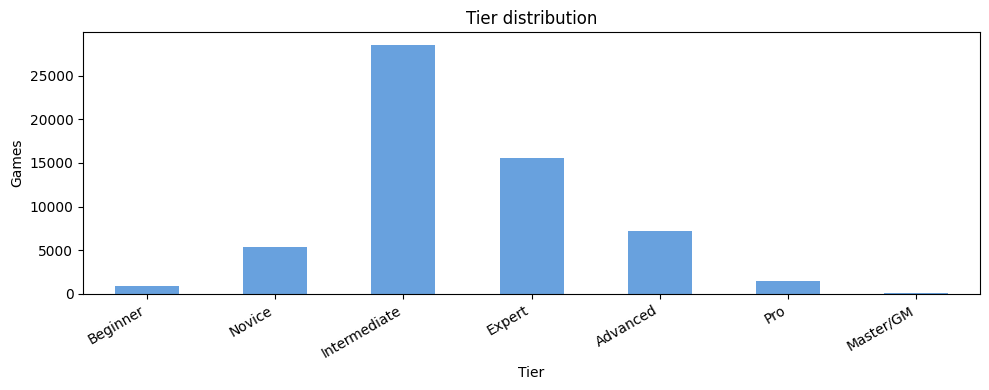

In [6]:
_BOARD_FEATURES = {
    'structure': ['total_ply_count', 'material_balance_end', 'result_encoded'],
    'checks':    ['checks_given_white', 'checks_given_black',
                  'check_density_white', 'check_density_black'],
    'captures':  ['first_capture_move_white', 'first_capture_move_black',
                  'pawn_captures_total', 'piece_captures_total', 'capture_density'],
    'castling':  ['castle_move_white', 'castle_move_black'],
    'style':     ['consec_same_piece_white', 'consec_same_piece_black',
                  'queen_moves_before_10', 'white_territory_depth', 'black_territory_depth',
                  'promotions', 'en_passant_captures',
                  'legal_moves_white_move5', 'legal_moves_black_move5'],
    'engine':    ['acpl_white', 'inaccuracy_count_white', 'mistake_count_white',
                  'blunder_count_white', 'blunder_density_white',
                  'acpl_black', 'inaccuracy_count_black', 'mistake_count_black',
                  'blunder_count_black', 'blunder_density_black'],
}
_CLOCK_FEATURES = [
    'avg_time_norm_white', 'std_time_norm_white', 'max_time_norm_white',
    'time_pressure_white', 'opening_pace_norm_white', 'clock_remaining_norm_white',
    'opening_time_norm_white', 'endgame_time_norm_white', 'time_spent_trend_norm_white',
    'avg_time_norm_black', 'std_time_norm_black', 'max_time_norm_black',
    'time_pressure_black', 'opening_pace_norm_black', 'clock_remaining_norm_black',
    'opening_time_norm_black', 'endgame_time_norm_black', 'time_spent_trend_norm_black',
]
_CASTLE_CAT = ['castle_side_white', 'castle_side_black'] if FEATURE_GROUPS['castling'] else []
_META_CAT   = []
if FEATURE_GROUPS['meta']:
    _META_CAT = ['TimeControl', 'ECO_Group'] if ECO_COARSE_LEVEL == 'letter' else ['TimeControl', 'ECO']
_TC_NUMERIC = ['tc_base', 'tc_increment'] if ADD_TIME_CONTROL_NUMERIC else []

NUMERIC_FEATURES     = []
for grp, cols in _BOARD_FEATURES.items():
    if FEATURE_GROUPS.get(grp, False):
        NUMERIC_FEATURES += cols
if FEATURE_GROUPS['clock']:
    NUMERIC_FEATURES += _CLOCK_FEATURES
NUMERIC_FEATURES += _TC_NUMERIC
CATEGORICAL_FEATURES = _CASTLE_CAT + _META_CAT

# ── merge ──────────────────────────────────────────────────────────────────────
meta_cols = ['WhiteElo', 'BlackElo']
if FEATURE_GROUPS['meta']:
    meta_cols += ['TimeControl', 'ECO']
if ADD_TIME_CONTROL_NUMERIC:
    meta_cols += ['tc_base', 'tc_increment']
meta_cols = list(dict.fromkeys([c for c in meta_cols if c in df_raw.columns]))

df = (
    df_raw[meta_cols]
    .join(df_feats, how='inner')
    .join(df_clocks, how='inner')
)
df = df.replace([np.inf, -np.inf], np.nan)

if FEATURE_GROUPS['meta'] and ECO_COARSE_LEVEL == 'letter' and 'ECO' in df.columns:
    df['ECO_Group'] = df['ECO'].astype(str).str[0].fillna('U')

if FILTER_SHORT_GAMES and 'total_ply_count' in df.columns:
    before = len(df)
    df = df[df['total_ply_count'] >= MIN_TOTAL_PLIES].copy().reset_index(drop=True)
    print(f'Short-game filter (<{MIN_TOTAL_PLIES} plies): dropped {before-len(df):,}')

# ── Elo target → tier label ────────────────────────────────────────────────────
if ELO_TARGET == 'avg':
    elo_vals = (df['WhiteElo'] + df['BlackElo']) / 2
elif ELO_TARGET == 'WhiteElo':
    elo_vals = df['WhiteElo']
else:
    elo_vals = df['BlackElo']

df['elo_for_tier'] = elo_vals
df['tier_label']   = pd.cut(
    elo_vals,
    bins=TIER_BINS,
    labels=TIER_NAMES,
    right=True,
)
df = df.dropna(subset=['tier_label']).copy().reset_index(drop=True)
df['tier_int'] = df['tier_label'].cat.codes   # integer label for models

print(f'DataFrame: {df.shape}')
print('Tier distribution:')
print(df['tier_label'].value_counts().sort_index())

if VERBOSE_PLOTS:
    fig, ax = plt.subplots(figsize=(10, 4))
    df['tier_label'].value_counts().loc[TIER_NAMES].plot(
        kind='bar', ax=ax, color='#4e91d9', edgecolor='none', alpha=0.85
    )
    ax.set_xlabel('Tier'); ax.set_ylabel('Games')
    ax.set_title('Tier distribution')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()


## 5 · Preprocessor + feature matrix

In [7]:
def build_preprocessor(numeric_cols, categorical_cols):
    transformers = [('num', SimpleImputer(strategy='median'), numeric_cols)]
    if categorical_cols:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        )
    return ColumnTransformer(transformers=transformers, remainder='drop')

_num_cols = [c for c in NUMERIC_FEATURES    if c in df.columns]
_cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]
preprocessor = build_preprocessor(_num_cols, _cat_cols)
X_all        = preprocessor.fit_transform(df)
feat_names   = list(preprocessor.get_feature_names_out())

y_all = df['tier_int'].values
print(f'Feature matrix : {X_all.shape}')
print(f'Classes (0-idx): {np.unique(y_all)}')


Feature matrix : (59122, 49)
Classes (0-idx): [0 1 2 3 4 5 6]


## 6 · Train / Val / Test split + sample weights

Train: 47,296  Val: 5,913  Test: 5,913
Tier counts (test set): {'Beginner': np.int64(93), 'Novice': np.int64(536), 'Intermediate': np.int64(2856), 'Expert': np.int64(1557), 'Advanced': np.int64(723), 'Pro': np.int64(141), 'Master/GM': np.int64(7)}


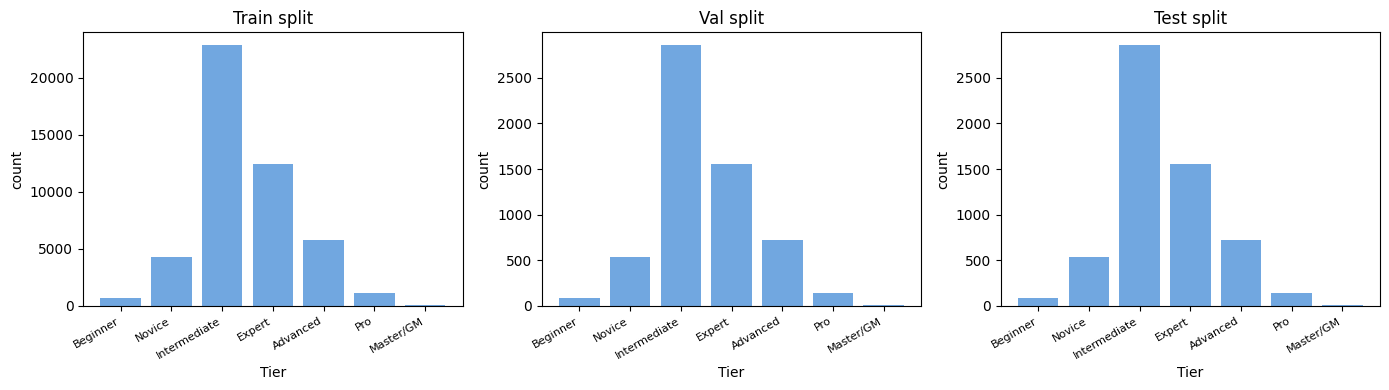

In [8]:
idx = np.arange(len(df))

idx_tv, idx_test = train_test_split(
    idx, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)
_val_frac = VAL_SIZE / (1 - TEST_SIZE)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=_val_frac, stratify=y_all[idx_tv], random_state=RANDOM_STATE
)

X_train, X_val, X_test = X_all[idx_train], X_all[idx_val], X_all[idx_test]
y_train, y_val, y_test  = y_all[idx_train], y_all[idx_val], y_all[idx_test]

# Balanced class weights for training
sample_weights = compute_sample_weight('balanced', y_train)

print(f'Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}')
print('Tier counts (test set):', dict(zip(TIER_NAMES, np.bincount(y_test, minlength=_N_CLASSES))))

if VERBOSE_PLOTS:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, split, y_split in zip(axes, ['Train', 'Val', 'Test'],
                                   [y_train, y_val, y_test]):
        counts = np.bincount(y_split, minlength=_N_CLASSES)
        ax.bar(TIER_NAMES, counts, color='#4e91d9', alpha=0.8)
        ax.set_title(f'{split} split'); ax.set_xlabel('Tier'); ax.set_ylabel('count')
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    plt.tight_layout(); plt.show()


## 7 · Hyperparameter search (toggle `RUN_HYPERPARAM_SEARCH`)

In [9]:
if MODEL_BACKEND == 'lgbm':
    _base_clf   = lgb.LGBMClassifier(**{k:v for k,v in LGBM_PARAMS.items()
                                         if k not in ('num_class',)})
    _search_spc = LGBM_SEARCH_SPACE
else:
    _base_clf   = xgb.XGBClassifier(**{k:v for k,v in XGB_PARAMS.items()
                                        if k not in ('num_class',)})
    _search_spc = XGB_SEARCH_SPACE

best_params = (LGBM_PARAMS if MODEL_BACKEND == 'lgbm' else XGB_PARAMS).copy()

if RUN_HYPERPARAM_SEARCH and not LOAD_PRETRAINED:
    print(f'Randomised search ({MODEL_BACKEND.upper()}) — {HYPERPARAM_N_ITER} iters...')
    search = RandomizedSearchCV(
        _base_clf, _search_spc,
        n_iter=HYPERPARAM_N_ITER,
        cv=StratifiedKFold(n_splits=HYPERPARAM_CV_FOLDS, shuffle=True,
                            random_state=RANDOM_STATE),
        scoring='balanced_accuracy',
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X_train, y_train, sample_weight=sample_weights)
    best_params.update(search.best_params_)
    print('Best params:', search.best_params_)
    print(f'Best CV balanced-acc: {search.best_score_:.4f}')
elif LOAD_PRETRAINED:
    print('Hyperparam search skipped — loading pretrained model')
else:
    print(f'Hyperparam search skipped — using {MODEL_BACKEND.upper()} default params')


Hyperparam search skipped — using LGBM default params


## 8 · Train

In [10]:
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# ── model factory ──────────────────────────────────────────────────────────────
def make_model(backend: str, params: dict):
    """Return a fresh (unfitted) classifier for the given backend."""
    if backend == 'lgbm':
        kw = {k: v for k, v in params.items() if k != 'num_class'}
        return lgb.LGBMClassifier(**kw)
    elif backend == 'xgb':
        kw = {k: v for k, v in params.items() if k != 'num_class'}
        return xgb.XGBClassifier(**kw)
    raise ValueError(f'Unknown backend: {backend}')


def fit_model(model, backend: str):
    """Backend-aware fitting with early stopping."""
    if backend == 'lgbm':
        model.fit(
            X_train, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=0)],
        )
    elif backend == 'xgb':
        model.fit(
            X_train, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
    return model


def save_model(model, backend: str, suffix: str = '') -> str:
    fname = f'{MODEL_SAVE_NAME}_{MODEL_SAVE_NOTES}{suffix}_{_ts}'
    if backend == 'lgbm':
        fname += '.txt'
        model.booster_.save_model(fname)
    elif backend == 'xgb':
        fname += '.ubj'
        model.save_model(fname)
    return fname


def load_model(path: str, backend: str, params: dict):
    model = make_model(backend, params)
    if backend == 'lgbm':
        model.booster_ = lgb.Booster(model_file=path)
        n = model.booster_.num_feature()
        model._n_features = n; model._n_features_in = n
    elif backend == 'xgb':
        model.load_model(path)
    return model


# ── train or load ──────────────────────────────────────────────────────────────
if LOAD_PRETRAINED:
    if not PRETRAINED_PATH or not os.path.exists(PRETRAINED_PATH):
        raise FileNotFoundError(f'Model not found: {PRETRAINED_PATH}')
    print(f'Loading pretrained {MODEL_BACKEND.upper()} from {PRETRAINED_PATH}...')
    clf = load_model(PRETRAINED_PATH, MODEL_BACKEND, best_params)
else:
    print(f'Training {MODEL_BACKEND.upper()}...')
    t0  = time.time()
    clf = make_model(MODEL_BACKEND, best_params)
    clf = fit_model(clf, MODEL_BACKEND)
    elapsed = time.time() - t0
    print(f'Training done in {elapsed:.1f}s')
    fname = save_model(clf, MODEL_BACKEND)
    print(f'Saved → {fname}')


Training LGBM...
Training done in 15.0s
Saved → tier_clf_lgbm_500k_600s_20260601_155811.txt


## 9 · Evaluate

In [11]:
val_proba  = clf.predict_proba(X_val)
test_proba = clf.predict_proba(X_test)

val_preds  = np.argmax(val_proba,  axis=1)
test_preds = np.argmax(test_proba, axis=1)

val_acc    = accuracy_score(y_val,  val_preds)
test_acc   = accuracy_score(y_test, test_preds)
test_bal   = balanced_accuracy_score(y_test, test_preds)
test_top2  = top_k_accuracy_score(y_test, test_proba, k=2)
test_top3  = top_k_accuracy_score(y_test, test_proba, k=3)

print(f'  Val  Accuracy          : {val_acc:.4f}')
print(f'  Test Accuracy          : {test_acc:.4f}')
print(f'  Test Balanced-Accuracy : {test_bal:.4f}')
print(f'  Test Top-2 Accuracy    : {test_top2:.4f}')
print(f'  Test Top-3 Accuracy    : {test_top3:.4f}')
print()
print(classification_report(y_test, test_preds,
                             target_names=TIER_NAMES,
                             digits=3))


  Val  Accuracy          : 0.3455
  Test Accuracy          : 0.3416
  Test Balanced-Accuracy : 0.2373
  Test Top-2 Accuracy    : 0.6592
  Test Top-3 Accuracy    : 0.8733

              precision    recall  f1-score   support

    Beginner      0.089     0.043     0.058        93
      Novice      0.201     0.438     0.276       536
Intermediate      0.573     0.326     0.416      2856
      Expert      0.321     0.358     0.339      1557
    Advanced      0.224     0.382     0.282       723
         Pro      0.155     0.113     0.131       141
   Master/GM      0.000     0.000     0.000         7

    accuracy                          0.342      5913
   macro avg      0.223     0.237     0.214      5913
weighted avg      0.412     0.342     0.353      5913



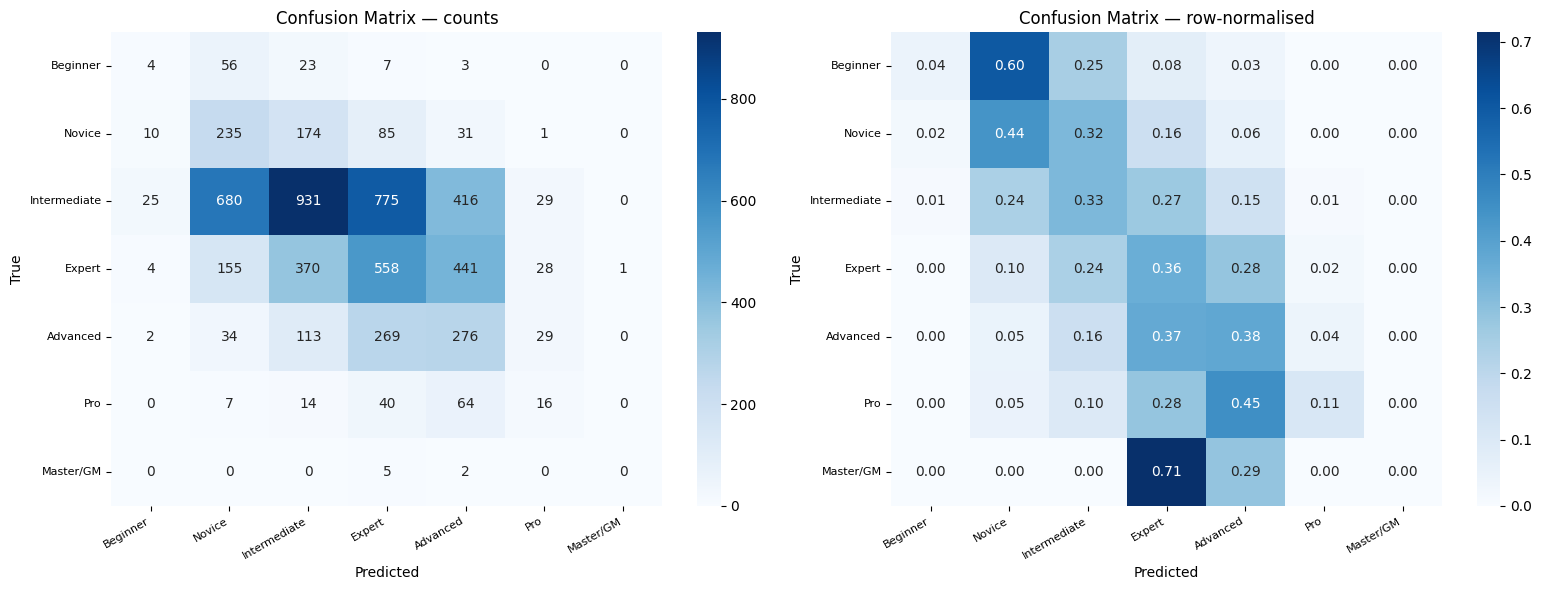

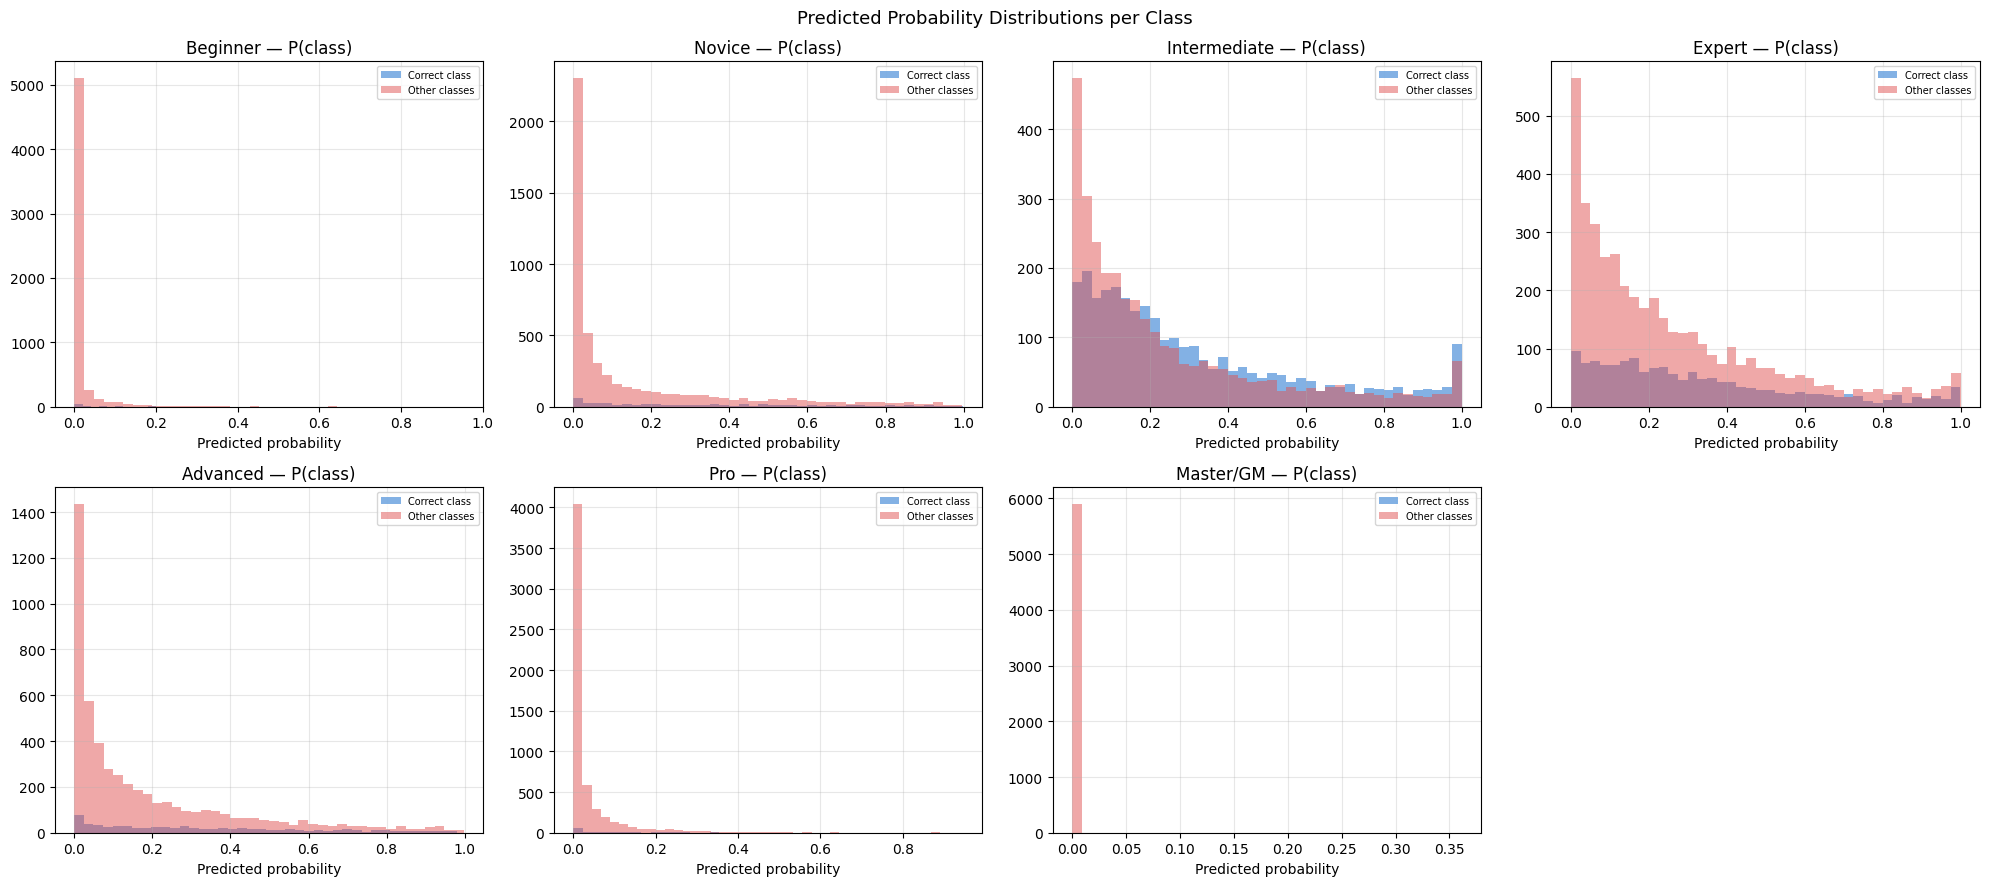

In [12]:
if VERBOSE_PLOTS:
    # ── confusion matrix ───────────────────────────────────────────────────────
    cm      = confusion_matrix(y_test, test_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, mat, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Confusion Matrix — counts', 'Confusion Matrix — row-normalised'],
    ):
        sns.heatmap(
            mat, annot=True, fmt=fmt, cmap='Blues',
            xticklabels=TIER_NAMES, yticklabels=TIER_NAMES,
            ax=ax, cbar=True,
        )
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout(); plt.show()

    # ── per-class probability distributions ───────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes_flat = axes.flatten()
    for i, name in enumerate(TIER_NAMES):
        ax    = axes_flat[i]
        mask  = y_test == i
        ax.hist(test_proba[mask,  i], bins=40, alpha=0.7, color='#4e91d9',
                label='Correct class')
        ax.hist(test_proba[~mask, i], bins=40, alpha=0.5, color='#e05252',
                label='Other classes')
        ax.set_title(f'{name} — P(class)')
        ax.set_xlabel('Predicted probability'); ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
    for j in range(len(TIER_NAMES), len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.suptitle('Predicted Probability Distributions per Class', fontsize=13)
    plt.tight_layout(); plt.show()


## 10 · Feature importance

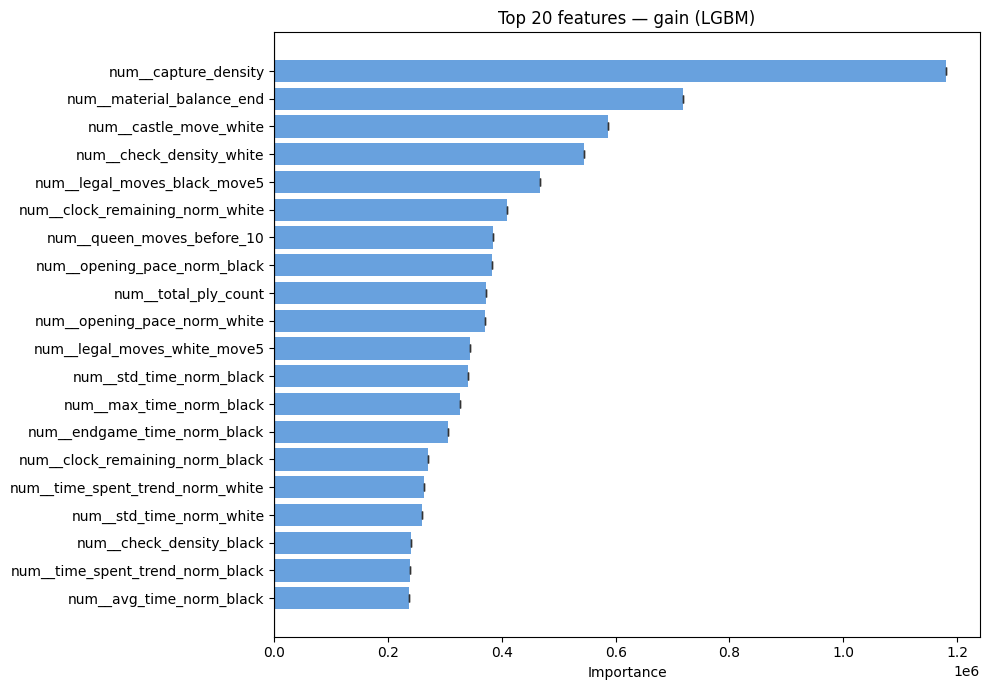

In [13]:
perm_df = None

if RUN_PERM_IMPORTANCE:
    _method = str(FEATURE_IMPORTANCE_METHOD).strip().lower()

    def compute_importance(method: str) -> pd.DataFrame:
        if method == 'permutation':
            print(f'Permutation importance ({PERM_N_REPEATS} repeats)...')
            t0 = time.time()
            result = permutation_importance(
                clf, X_test, y_test,
                n_repeats=PERM_N_REPEATS,
                scoring='balanced_accuracy',
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE,
            )
            print(f'  done in {time.time()-t0:.1f}s')
            n = len(feat_names)
            return pd.DataFrame({
                'feature':    feat_names[:n],
                'importance': result.importances_mean[:n],
                'std':        result.importances_std[:n],
            }).sort_values('importance', ascending=False).reset_index(drop=True)

        if MODEL_BACKEND == 'lgbm':
            booster    = clf.booster_
            importances = booster.feature_importance(importance_type=method)
        elif MODEL_BACKEND == 'xgb':
            itype = 'total_gain' if method == 'gain' else 'weight'
            scores = clf.get_booster().get_score(importance_type=itype)
            importances = np.array([scores.get(f, 0.) for f in feat_names])

        n = len(feat_names)
        return pd.DataFrame({
            'feature':    feat_names[:n],
            'importance': importances[:n],
            'std':        np.zeros(n, dtype=float),
        }).sort_values('importance', ascending=False).reset_index(drop=True)

    perm_df = compute_importance(_method)

    if VERBOSE_PLOTS:
        top = perm_df.head(TOP_N_FEATURES).iloc[::-1]
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(top['feature'], top['importance'], xerr=top['std'],
                color='#4e91d9', ecolor='#333', capsize=3, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(f'Top {TOP_N_FEATURES} features — {_method} ({MODEL_BACKEND.upper()})')
        ax.set_xlabel('Importance')
        plt.tight_layout(); plt.show()
else:
    print('Feature importance skipped (RUN_PERM_IMPORTANCE=False)')


## 11 · Retrain on top-N features (toggle `RETRAIN_TOP_N`)

In [14]:
if RETRAIN_TOP_N and perm_df is not None:
    top_feats = perm_df.head(TOP_N_FEATURES)['feature'].tolist()
    print(f'Retraining on top {TOP_N_FEATURES} features: {top_feats}')

    _top_idx  = [feat_names.index(f) for f in top_feats if f in feat_names]
    X_tr_top  = X_all[idx_train][:, _top_idx]
    X_v_top   = X_all[idx_val][:,   _top_idx]
    X_te_top  = X_all[idx_test][:,  _top_idx]

    clf_top = make_model(MODEL_BACKEND, best_params)
    if MODEL_BACKEND == 'lgbm':
        clf_top.fit(
            X_tr_top, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_v_top, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=0)],
        )
    else:
        clf_top.fit(
            X_tr_top, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_v_top, y_val)],
            verbose=False,
        )

    top_preds = np.argmax(clf_top.predict_proba(X_te_top), axis=1)
    print(f'Top-{TOP_N_FEATURES} test accuracy : {accuracy_score(y_test, top_preds):.4f}')
    print(f'Top-{TOP_N_FEATURES} balanced-acc  : {balanced_accuracy_score(y_test, top_preds):.4f}')
    fname = save_model(clf_top, MODEL_BACKEND, suffix=f'_top{TOP_N_FEATURES}')
    print(f'Saved → {fname}')
else:
    if not RETRAIN_TOP_N:
        print('Top-N retrain skipped (RETRAIN_TOP_N=False)')
    else:
        print('Top-N retrain skipped — run feature importance first')


Top-N retrain skipped (RETRAIN_TOP_N=False)


## 12 · Summary table

In [15]:
rows = [
    {
        'run':             f'{MODEL_BACKEND.upper()} full',
        'features':        X_all.shape[1],
        'val_accuracy':    val_acc,
        'test_accuracy':   test_acc,
        'balanced_acc':    test_bal,
        'top2_accuracy':   test_top2,
        'top3_accuracy':   test_top3,
    }
]
if RETRAIN_TOP_N and perm_df is not None:
    rows.append({
        'run':           f'{MODEL_BACKEND.upper()} top-{TOP_N_FEATURES}',
        'features':      TOP_N_FEATURES,
        'test_accuracy': accuracy_score(y_test, top_preds),
        'balanced_acc':  balanced_accuracy_score(y_test, top_preds),
    })
pd.DataFrame(rows).round(4)


,run,features,val_accuracy,test_accuracy,balanced_acc,top2_accuracy,top3_accuracy
0,LGBM full,49,0.3455,0.3416,0.2373,0.6592,0.8733


## 13 · ROC curves (one-vs-rest)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# One-vs-rest ROC for multiclass
classes = np.arange(_N_CLASSES)
y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}
for i in classes:
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
mean_tpr = np.zeros_like(all_fpr)
for i in classes:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(9, 7))
plt.plot(fpr["micro"], tpr["micro"],
         label=f"micro-average (AUC = {roc_auc['micro']:.3f})",
         color="#1f77b4", linewidth=2)
plt.plot(fpr["macro"], tpr["macro"],
         label=f"macro-average (AUC = {roc_auc['macro']:.3f})",
         color="#ff7f0e", linewidth=2)

# Per-class curves (lighter)
for i in classes:
    plt.plot(fpr[i], tpr[i], linewidth=1,
             label=f"{TIER_NAMES[i]} (AUC = {roc_auc[i]:.3f})", alpha=0.6)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — one-vs-rest")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()